In [1]:
import numpy as np
import pandas as pd
import numba as nb
from typing import Tuple

# TC因子

In [2]:
@nb.jit(nopython=True)
def numba_linregress(x: np.ndarray, y: np.ndarray) -> Tuple[float, float, float]:
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x **2)
    denominator = n * sum_x2 - sum_x** 2
    if denominator == 0:
        return np.nan, np.nan, np.nan
    slope = (n * sum_xy - sum_x * sum_y) / denominator
    intercept = (sum_y - slope * sum_x) / n
    # 计算R²
    y_pred = intercept + slope * x
    ss_total = sum((y - np.mean(y)) **2)
    ss_residual = sum((y - y_pred)** 2)
    r_squared = 1 - (ss_residual / ss_total) if ss_total != 0 else np.nan
    return slope, intercept, r_squared
@nb.jit(nopython=True)
def calculate_tc_roll(window: np.ndarray, n: int) -> float:
    if window.shape[0] < 4 * n:
        return np.nan
    x = np.arange(window.shape[0])
    _, _, r_squared = numba_linregress(x, window)
    return r_squared
def compute_tc(df: pd.DataFrame, price_col: str = 'close_price', n: int = 24) -> pd.Series:
    window_size = 11 * n
    tc = df[price_col].rolling(
        window=window_size, 
        min_periods=4*n
    ).apply(
        lambda x: calculate_tc_roll(x.to_numpy(), n), 
        raw=False
    )
    return tc.rename(f'TC_{n}')

# PWMA因子

In [3]:
@nb.jit(nopython=True)
def numba_comb(n: int, k: int) -> int:
    if k < 0 or k > n:
        return 0
    if k == 0 or k == n:
        return 1
    k = min(k, n - k)
    result = 1
    for i in range(k):
        result = result * (n - i) // (i + 1)
    return result
@nb.jit(nopython=True)
def get_pwma_weights(window_size: int) -> np.ndarray:
    weights = np.zeros(window_size, dtype=np.float64)
    for k in range(window_size):
        weights[k] = numba_comb(window_size - 1, k)
    return weights / np.sum(weights)
def compute_pwma(df: pd.DataFrame, price_col: str = 'close_price', window: int = 14) -> pd.Series:
    weights = get_pwma_weights(window)
    prices = df[price_col].to_numpy()
    pwma = np.convolve(prices, weights, mode='same')
    # 过滤边缘
    pwma[:window//2] = np.nan
    pwma[-window//2:] = np.nan
    return pd.Series(pwma, index=df.index, name=f'PWMA_{window}')

# CTO因子

In [4]:
@nb.jit(nopython=True)
def forecast_window_numba(window: np.ndarray) -> float:
    period = len(window)
    if period < 2:
        return np.nan
    x = np.arange(period)
    slope, intercept, _ = numba_linregress(x, window)
    return intercept + slope * period  #预测下一期价格
def compute_cfo(df: pd.DataFrame, price_col: str = 'close_price', period: int = 14) -> pd.Series:
   
    def forecast_window(window: pd.Series) -> float:
        return forecast_window_numba(window.to_numpy())  
    #滚动计算预测值
    forecasts = df[price_col].rolling(window=period).apply(forecast_window, raw=False)
    #CFO公式：(实际价格-预测价格)/实际价格 * 100
    cfo = (df[price_col] - forecasts) / df[price_col] * 100
    return cfo.rename(f'CFO_{period}')

# 验证

----- 虚拟货币因子分析-----

【步骤1/4：数据检验与下载】
 本地已存在 BTC 数据（BTC_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 ETH 数据（ETH_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 SOL 数据（SOL_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 BNB 数据（BNB_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 ADA 数据（ADA_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 XRP 数据（XRP_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 DOT 数据（DOT_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 DOGE 数据（DOGE_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 LINK 数据（LINK_USD_hourly_20240914_to_20250914.csv），无需重新下载
 本地已存在 LTC 数据（LTC_USD_hourly_20240914_to_20250914.csv），无需重新下载

【步骤2/4：加载虚拟货币数据】
 加载 BTC 数据成功（8760 条记录）：BTC_USD_hourly_20240914_to_20250914.csv
 加载 ETH 数据成功（8760 条记录）：ETH_USD_hourly_20240914_to_20250914.csv
 加载 SOL 数据成功（8760 条记录）：SOL_USD_hourly_20240914_to_20250914.csv
 加载 BNB 数据成功（8760 条记录）：BNB_USD_hourly_20240914_to_20250914.csv
 加载 ADA 数据成功（8760 条记录）：ADA_USD_hourly_20240914_to_20250914.csv
 加载 XR

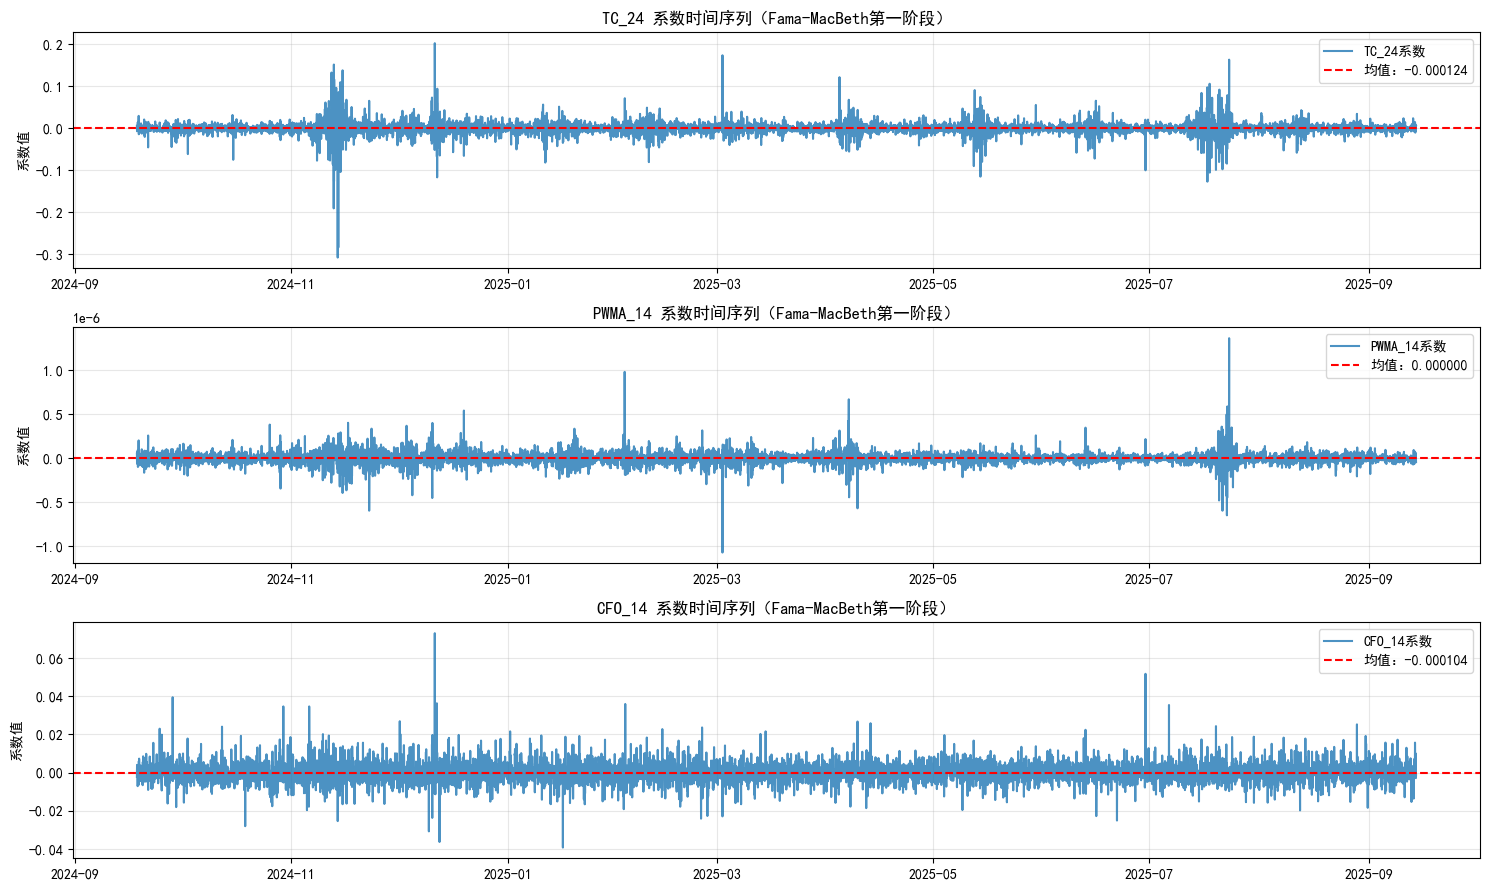

 因子系数时间序列图已保存至：C:\Users\86157\Python机器学习与应用\crypto_factor_plots\factor_coefficients_time_series.png


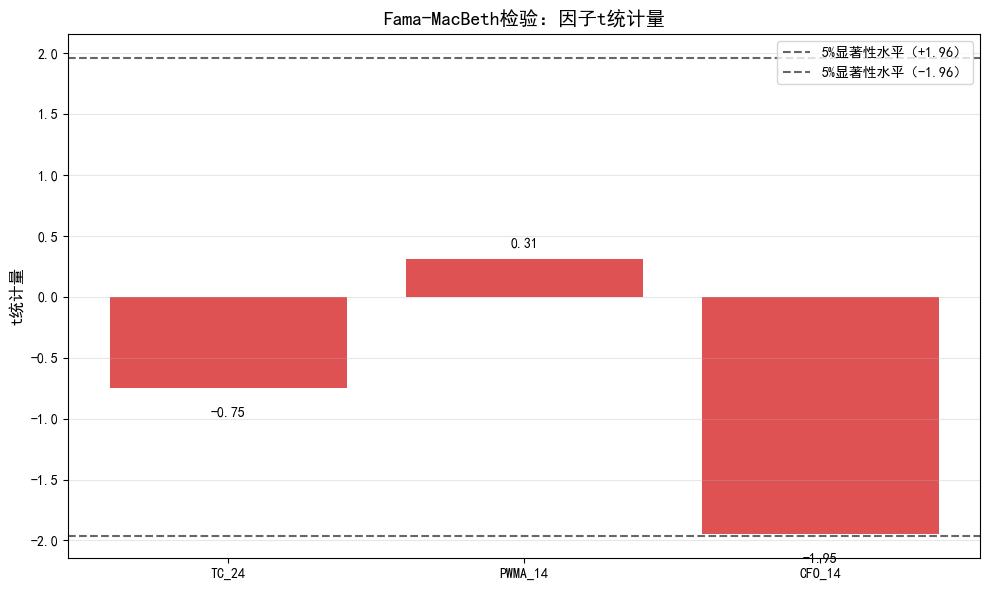

 因子t统计量图已保存至：C:\Users\86157\Python机器学习与应用\crypto_factor_plots\factor_t_statistics.png


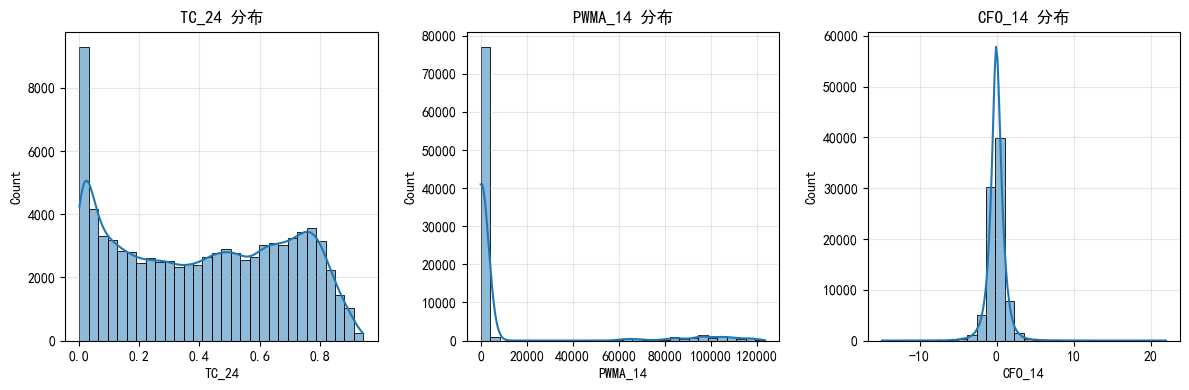

 因子分布图已保存至：C:\Users\86157\Python机器学习与应用\crypto_factor_plots\factor_distributions.png

Fama-MacBeth检验最终结果（5%显著性水平）
          mean_coef    t_stat   p_value significant_5pct
intercept  0.000123  0.920195  0.357471                否
TC_24     -0.000124 -0.751572  0.452309                否
PWMA_14         0.0  0.306398  0.759302                否
CFO_14    -0.000104 -1.949677  0.051215                否

 所有流程执行完成！
 数据文件位置：C:\Users\86157\Python机器学习与应用\crypto_data
 图表文件位置：C:\Users\86157\Python机器学习与应用\crypto_factor_plots


In [2]:
import numpy as np
import pandas as pd
import numba as nb
import time
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy import stats
from sklearn.linear_model import LinearRegression
from typing import Tuple
import os
from datetime import datetime, timedelta

#数据下载模块
def get_crypto_hourly_data(symbol: str, vs_currency: str = "USD", days: int = 365) -> pd.DataFrame:
    end_time = int(datetime.now().timestamp())
    start_time = int((datetime.now() - timedelta(days=days)).timestamp())
    url = "https://min-api.cryptocompare.com/data/v2/histohour"
    all_data = []
    current_end_time = end_time
    
    print(f"开始获取 {symbol}/{vs_currency} 数据...")
    while current_end_time > start_time:
        remaining_hours = int((current_end_time - start_time) / 3600)
        limit = min(719, remaining_hours)
        
        params = {
            "fsym": symbol,
            "tsym": vs_currency,
            "limit": limit,
            "toTs": current_end_time
        }
        
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            
            if data["Response"] == "Success":
                current_data = data["Data"]["Data"]
                if current_data:
                    all_data.extend(current_data)
                    current_end_time = current_data[0]["time"] - 3600
                    print(f"已获取 {len(all_data)} 条 {symbol} 数据...")
                else:
                    break
            else:
                print(f"API错误 ({symbol}): {data['Message']}")
                return pd.DataFrame()
                
        except requests.exceptions.RequestException as e:
            print(f"请求失败 ({symbol}): {str(e)}")
            return pd.DataFrame()
        
        time.sleep(1)
    
    if all_data:
        df = pd.DataFrame(all_data)
        df["timestamp"] = pd.to_datetime(df["time"], unit="s")
        df = df[["timestamp", "open", "high", "low", "close", "volumefrom", "volumeto"]]
        df = df.rename(columns={
            "open": "open_price", "high": "high_price", "low": "low_price",
            "close": "close_price", "volumefrom": "volume_from", "volumeto": "volume_to"
        })
        df = df.sort_values("timestamp").reset_index(drop=True)
        print(f" 成功获取 {symbol} 数据（{len(df)} 条记录）")
        return df
    else:
        print(f" 未获取到 {symbol} 数据")
        return pd.DataFrame()

def check_and_download_cryptos(crypto_list: list, vs_currency: str = "USD", 
                              days: int = 365, folder: str = "data") -> None:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"创建数据存储文件夹: {os.path.abspath(folder)}")
    
    for symbol in crypto_list:
        local_files = [f for f in os.listdir(folder) if 
                      f.startswith(f"{symbol}_{vs_currency}_hourly_") and 
                      f.endswith(".csv")]
        
        if local_files:
            print(f" 本地已存在 {symbol} 数据（{local_files[0]}），无需重新下载")
            continue
        
        df = get_crypto_hourly_data(symbol, vs_currency, days)
        if not df.empty:
            start_date = df["timestamp"].min().strftime("%Y%m%d")
            end_date = df["timestamp"].max().strftime("%Y%m%d")
            filename = f"{symbol}_{vs_currency}_hourly_{start_date}_to_{end_date}.csv"
            filepath = os.path.join(folder, filename)
            df.to_csv(filepath, index=False)
            print(f" {symbol} 数据已保存至: {os.path.abspath(filepath)}\n")
        
        time.sleep(2)

#因子计算核心函数
@nb.jit(nopython=True)
def numba_linregress(x: np.ndarray, y: np.ndarray) -> Tuple[float, float, float]:
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan
    
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)
    
    denominator = n * sum_x2 - sum_x ** 2
    if denominator == 0:
        return np.nan, np.nan, np.nan
    
    slope = (n * sum_xy - sum_x * sum_y) / denominator
    intercept = (sum_y - slope * sum_x) / n
    
    y_pred = intercept + slope * x
    ss_total = sum((y - np.mean(y)) ** 2)
    ss_residual = sum((y - y_pred) ** 2)
    r_squared = 1 - (ss_residual / ss_total) if ss_total != 0 else np.nan
    
    return slope, intercept, r_squared

@nb.jit(nopython=True)
def calculate_tc_roll(window: np.ndarray, n: int) -> float:
    if window.shape[0] < 4 * n:
        return np.nan
    x = np.arange(window.shape[0])
    _, _, r_squared = numba_linregress(x, window)
    return r_squared

def compute_tc(df: pd.DataFrame, price_col: str, n: int) -> pd.Series:
    window_size = 11 * n
    tc = df[price_col].rolling(
        window=window_size, 
        min_periods=4*n
    ).apply(
        lambda x: calculate_tc_roll(x.to_numpy(), n), 
        raw=False
    )
    return tc.rename(f'TC_{n}')

@nb.jit(nopython=True)
def numba_comb(n: int, k: int) -> int:
    if k < 0 or k > n:
        return 0
    if k == 0 or k == n:
        return 1
    k = min(k, n - k)
    result = 1
    for i in range(k):
        result = result * (n - i) // (i + 1)
    return result

def compute_pwma(df: pd.DataFrame, price_col: str, window: int) -> pd.Series:
    @nb.jit(nopython=True)
    def get_weights(window_size: int) -> np.ndarray:
        weights = np.zeros(window_size, dtype=np.float64)
        for k in range(window_size):
            weights[k] = numba_comb(window_size - 1, k)
        return weights / np.sum(weights)
    
    weights = get_weights(window)
    prices = df[price_col].to_numpy()
    pwma = np.convolve(prices, weights, mode='same')
    pwma[:window//2] = np.nan
    pwma[-window//2:] = np.nan
    return pd.Series(pwma, index=df.index, name=f'PWMA_{window}')

def compute_cfo(df: pd.DataFrame, price_col: str, period: int) -> pd.Series:
    @nb.jit(nopython=True)
    def forecast_window_numba(window: np.ndarray) -> float:
        if len(window) < period:
            return np.nan
        x = np.arange(len(window))
        slope, intercept, _ = numba_linregress(x, window)
        return intercept + slope * len(window)
    
    def forecast_window(window: pd.Series) -> float:
        return forecast_window_numba(window.to_numpy())
    
    forecasts = df[price_col].rolling(window=period).apply(forecast_window, raw=False)
    cfo = (df[price_col] - forecasts) / df[price_col] * 100
    return cfo.rename(f'CFO_{period}')

def compute_all_factors(df: pd.DataFrame, price_col: str = 'close_price',
                       tc_n: int = 24, pwma_window: int = 14, cfo_period: int = 14) -> pd.DataFrame:
    result = df.copy()
    result[f'TC_{tc_n}'] = compute_tc(result, price_col, tc_n)
    result[f'PWMA_{pwma_window}'] = compute_pwma(result, price_col, pwma_window)
    result[f'CFO_{cfo_period}'] = compute_cfo(result, price_col, cfo_period)
    return result

# 3. 数据加载模块
def load_downloaded_cryptos(crypto_list: list, vs_currency: str = "USD", folder: str = "data") -> dict:
    all_data = {}
    if not os.path.exists(folder):
        raise FileNotFoundError(f"数据文件夹 {folder} 不存在，请先执行数据下载步骤")
    
    for symbol in crypto_list:
        local_files = [f for f in os.listdir(folder) if 
                      f.startswith(f"{symbol}_{vs_currency}_hourly_") and 
                      f.endswith(".csv")]
        
        if not local_files:
            print(f"  未找到 {symbol} 本地数据，跳过该货币")
            continue
        
        csv_path = os.path.join(folder, local_files[0])
        try:
            df = pd.read_csv(csv_path)
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df = df.sort_values("timestamp").reset_index(drop=True)
            
            all_data[symbol] = df
            print(f" 加载 {symbol} 数据成功（{len(df)} 条记录）：{local_files[0]}")
        except Exception as e:
            print(f" 加载 {symbol} 数据失败：{str(e)}")
            continue
    
    if not all_data:
        raise ValueError(" 未加载到任何有效数据，请检查数据文件夹或重新下载")
    
    print(f"\n 数据加载完成：共加载 {len(all_data)} 种虚拟货币数据")
    return all_data

# 4. Fama-MacBeth检验
def prepare_panel_data(crypto_data: dict) -> pd.DataFrame:
    panel_list = []
    for crypto_name, df in crypto_data.items():
        if df.empty:
            continue
        
        factor_df = compute_all_factors(df)
        factor_df['next_return'] = factor_df['close_price'].pct_change(1).shift(-1)
        factor_df['crypto'] = crypto_name
        
        panel_list.append(factor_df)
    
    if not panel_list:
        raise ValueError(" 无有效数据构建面板")
    
    panel_data = pd.concat(panel_list, axis=0)
    valid_cols = ['next_return', 'TC_24', 'PWMA_14', 'CFO_14']
    panel_data = panel_data.dropna(subset=valid_cols)
    
    print(f" 面板数据准备完成：{len(panel_data)} 条有效记录（{len(panel_list)} 种货币）")
    return panel_data

def fama_macbeth_test(panel_data: pd.DataFrame, factors: list) -> Tuple[pd.DataFrame, pd.DataFrame]:
    time_groups = panel_data.groupby(panel_data['timestamp'])
    beta_list = []
    
    for time_idx, group in time_groups:
        if len(group) < 5:
            continue
        
        X = group[factors].to_numpy()
        y = group['next_return'].to_numpy()
        
        model = LinearRegression(fit_intercept=True)
        model.fit(X, y)
        
        beta_dict = {
            'time': time_idx,
            'intercept': model.intercept_
        }
        for factor, coef in zip(factors, model.coef_):
            beta_dict[factor] = coef
        
        beta_list.append(beta_dict)
    
    if not beta_list:
        raise ValueError(" 第一阶段回归无有效结果（样本量不足）")
    
    beta_df = pd.DataFrame(beta_list).set_index('time')
    n_time_obs = len(beta_df)
    result_dict = {}
    
    for col in beta_df.columns:
        mean_coef = beta_df[col].mean()
        std_coef = beta_df[col].std()
        t_stat = mean_coef / (std_coef / np.sqrt(n_time_obs))
        p_value = 2 * (1 - stats.norm.cdf(np.abs(t_stat)))
        
        result_dict[col] = {
            'mean_coef': mean_coef,
            'std_coef': std_coef,
            't_stat': t_stat,
            'p_value': p_value,
            'significant_5pct': '是' if p_value < 0.05 else '否'
        }
    
    fm_result = pd.DataFrame(result_dict).T
    return beta_df, fm_result

#可视化模块
def init_plot_folder(folder: str = "factor_plots") -> str:
    if not os.path.exists(folder):
        os.makedirs(folder)
    return os.path.abspath(folder)

def visualize_fm_results(beta_df: pd.DataFrame, fm_result: pd.DataFrame, panel_data: pd.DataFrame, 
                         plot_folder: str = "factor_plots", show_plot: bool = True) -> None:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    plot_folder = init_plot_folder(plot_folder)
    factors = [col for col in beta_df.columns if col != 'intercept']  #提取因子列表
    # 图1：因子系数时间序列图
    fig, axes = plt.subplots(len(factors), 1, figsize=(15, 3*len(factors)))
    for i, factor in enumerate(factors):
        ax = axes[i] if len(factors) > 1 else axes
        ax.plot(beta_df.index, beta_df[factor], label=f'{factor}系数', color='#1f77b4', alpha=0.8)
        ax.axhline(beta_df[factor].mean(), color='red', linestyle='--', 
                  label=f'均值：{beta_df[factor].mean():.6f}')
        ax.set_title(f'{factor} 系数时间序列（Fama-MacBeth第一阶段）', fontsize=12)
        ax.set_ylabel('系数值')
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    ts_path = os.path.join(plot_folder, 'factor_coefficients_time_series.png')
    plt.savefig(ts_path, dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()  
    plt.close()
    print(f" 因子系数时间序列图已保存至：{ts_path}")
    #因子t统计量条形图
    fm_result_no_intercept = fm_result.drop('intercept')
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#2ca02c' if row['significant_5pct'] == '是' else '#d62728' 
              for _, row in fm_result_no_intercept.iterrows()]
    bars = ax.bar(fm_result_no_intercept.index, fm_result_no_intercept['t_stat'], color=colors, alpha=0.8)
    
    ax.axhline(1.96, color='black', linestyle='--', alpha=0.6, label='5%显著性水平（+1.96）')
    ax.axhline(-1.96, color='black', linestyle='--', alpha=0.6, label='5%显著性水平（-1.96）')
    
    #添加数值标签
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., 
                height + (0.08 if height > 0 else -0.15),
                f'{height:.2f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=10)
    
    ax.set_title('Fama-MacBeth检验：因子t统计量', fontsize=14)
    ax.set_ylabel('t统计量', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    tstat_path = os.path.join(plot_folder, 'factor_t_statistics.png')
    plt.savefig(tstat_path, dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()  
    plt.close()
    print(f" 因子t统计量图已保存至：{tstat_path}")
    #因子分布直方图
    fig, axes = plt.subplots(1, len(factors), figsize=(4*len(factors), 4))
    for i, factor in enumerate(factors):
        ax = axes[i] if len(factors) > 1 else axes
        sns.histplot(panel_data[factor].dropna(), ax=ax, kde=True, bins=30)
        ax.set_title(f'{factor} 分布', fontsize=12)
        ax.set_xlabel(factor)
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    dist_path = os.path.join(plot_folder, 'factor_distributions.png')
    plt.savefig(dist_path, dpi=300, bbox_inches='tight')
    if show_plot:
        plt.show()  
    plt.close()
    print(f" 因子分布图已保存至：{dist_path}")

#主程序
if __name__ == "__main__":
    # 配置参数
    CRYPTO_LIST = ['BTC', 'ETH', 'SOL', 'BNB', 'ADA', 'XRP', 'DOT', 'DOGE', 'LINK', 'LTC']
    VS_CURRENCY = 'USD'
    DATA_FOLDER = 'crypto_data'
    PLOT_FOLDER = 'crypto_factor_plots'
    DAYS = 365
    FACTORS = ['TC_24', 'PWMA_14', 'CFO_14']
    print("----- 虚拟货币因子分析-----")
    #数据检验与下载
    print("\n【步骤1/4：数据检验与下载】")
    check_and_download_cryptos(CRYPTO_LIST, VS_CURRENCY, DAYS, DATA_FOLDER)
    #加载数据
    print("\n【步骤2/4：加载虚拟货币数据】")
    crypto_data = load_downloaded_cryptos(CRYPTO_LIST, VS_CURRENCY, DATA_FOLDER)
    #准备面板数据
    print("\n【步骤3/4：准备面板数据】")
    panel_data = prepare_panel_data(crypto_data)
    panel_path = os.path.join(DATA_FOLDER, 'crypto_panel_data_with_factors.csv')
    panel_data.to_csv(panel_path, index=False)
    print(f" 面板数据已保存至：{os.path.abspath(panel_path)}")
    #检验与可视化
    print("\n【步骤4/4：Fama-MacBeth检验与可视化】")
    beta_df, fm_result = fama_macbeth_test(panel_data, FACTORS)
    #保存检验结果
    beta_path = os.path.join(DATA_FOLDER, 'fama_macbeth_betas.csv')
    result_path = os.path.join(DATA_FOLDER, 'fama_macbeth_results.csv')
    beta_df.to_csv(beta_path)
    fm_result.to_csv(result_path)
    print(f" 第一阶段系数已保存至：{os.path.abspath(beta_path)}")
    print(f" 第二阶段结果已保存至：{os.path.abspath(result_path)}")
    #可视化
    visualize_fm_results(beta_df, fm_result, panel_data, PLOT_FOLDER, show_plot=True)
    #打印最终结果
    print("\n" + "="*70)
    print("Fama-MacBeth检验最终结果（5%显著性水平）")
    print("="*70)
    print(fm_result[['mean_coef', 't_stat', 'p_value', 'significant_5pct']].round(6))
    print("\n 所有流程执行完成！")
    print(f" 数据文件位置：{os.path.abspath(DATA_FOLDER)}")
    print(f" 图表文件位置：{os.path.abspath(PLOT_FOLDER)}")